# Введение в машинное обучение


## Теорема Байеса
Теорема Байеса — это фундаментальный результат теории вероятностей, который позволяет обновлять наши представления о вероятности события на основе новой информации. Она лежит в основе многих алгоритмов машинного обучения и является ключевым инструментом для принятия решений в условиях неопределенности.

<center>
<img src="../misc/images/bayes.png" alt="Описание изображения" />
</center>

### Задание 1. Условная вероятность
Прежде чем перейти к теореме Байеса, необходимо разобраться с понятием условной
вероятности. Условная вероятность P(A|B) показывает вероятность наступления события A при условии, что событие B уже произошло.

1. Напиши формулу условной вероятности в нотации LaTeX.
2. Реши следующую задачу: в коробке лежат 5 красных и 3 синих шара. Из коробки наугад вынимают два шара последовательно, без возврата. Какова вероятность того, что второй шар будет красным, если первый шар был синим? Вычисли ответ программно и выведи результат.
3. Реши следующую задачу: монету подбрасывают дважды. Событие A — первый бросок дал орла, событие B — второй бросок дал орла. Являются ли события A и B независимыми? Проверь это программно, вычислив P(A), P(B), P(A|B) и P(A и B). Сделай вывод о независимости событий.

P(A \mid B) = \frac{P(AB)}{P(B)}

In [12]:
red = 5
blue = 3
sum = red + blue

# Вероятность достать синий шарик
p1 = blue/sum

# Вероятность достать красный шарик
p2 = red/sum

# Вероятность того, что сначала выпал синий, а потом красный
p3 = (blue/sum)*(red/(sum - 1))

p = p3 / p1
p

0.7142857142857143

In [13]:
pa = 0.5
pb = 0.5

pab = pa*pb
paib = pab / pb

print(pa, pb, pab, paib)

# Вывод: если события независимые, то P(A|B) = P(A) и P(A^B) = P(A)*P(B)

0.5 0.5 0.25 0.5


### Задание 2. Тест на коронавирус

Теорема Байеса находит широкое применение в медицине, особенно при интерпретации результатов диагностических тестов.
<center>
<img src="../misc/images/error_type.png" alt="Типы ошибок" />
</center>

1. Напиши формулу теоремы Байеса в нотации LaTeX. Объясни, что означает каждый из компонентов формулы.
2. Дана задача: на планете живет 8 миллиардов человек. Известно, что заболел 1% населения. Тест на коронавирус имеет точность 95% (то есть 5% приходится на ошибки первого и второго рода: ложноположительные и ложноотрицательные результаты). Предположим, что вероятность ложноположительного результата (ошибка первого рода) составляет 5%, а вероятность ложноотрицательного результата (ошибка второго рода) составляет 5%. Ты сдал тест, и он оказался положительным. Какова вероятность того, что ты действительно болен? Реши задачу, используя теорему Байеса. Выведи результат с пояснениями.


P(A \mid B) = \frac{P(A \mid B) \cdot P(A)}{P(B)}

In [14]:
pd = 0.01 # человек болен
pnd = 0.99 # человек здоров

ppd = 0.95 # человек болен и тест +
ppnd = 0.05 # человек здоров и тест +

pmd = 0.05 # человек болен и тест -
pmnd = 0.95 # человек здоров и тест -

p = (ppd * pd)/(ppd * pd + ppnd * pnd)
p

0.16101694915254236

### Задание 3. Улучшаем тест

Результат предыдущей задачи показывает, что даже при высокой точности теста вероятность того, что человек действительно болен при положительном результате, может быть довольно низкой. Это связано с тем, что доля больных в популяции невелика (1%).

Врачи готовы улучшить тест, но могут исправить либо ошибку первого рода (ложноположительные результаты), либо ошибку второго рода (ложноотрицательные результаты). Необходимо выбрать, какую ошибку уменьшать.

<center>
<img src="../misc/images/dilemma.png" alt="Дилемма" />
</center>

1. Построй график зависимости вероятности P(болен|тест положительный) от изменения ошибки первого рода (ложноположительные результаты) при фиксированной ошибке второго рода (5%). Ошибка первого рода должна изменяться от 0% до 5% с шагом 0.5%.
2. Построй график зависимости вероятности P(болен|тест положительный) от изменения ошибки второго рода (ложноотрицательные результаты) при фиксированной ошибке первого рода (5%). Ошибка второго рода должна изменяться от 0% до 5% с шагом 0.5%.
3. Проанализируй оба графика и сделай вывод: какую ошибку следует уменьшать и почему? Объясни свой выбор, учитывая практические последствия ложноположительных и ложноотрицательных результатов в медицинской диагностике.

In [15]:
import matplotlib.pyplot as plt
import numpy as np

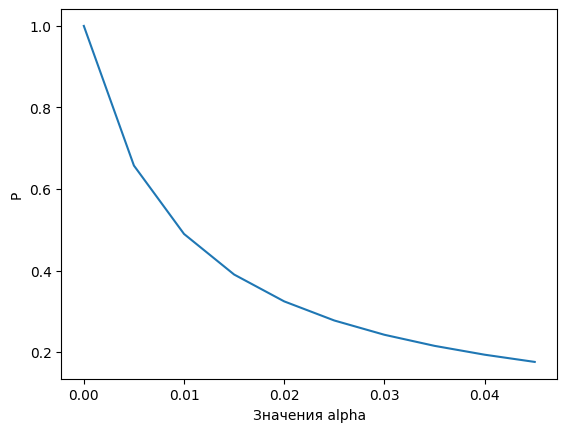

In [16]:
# Задача 1
beta = 0.05
p = 0.01

alpha_values = np.arange(0, 0.05, 0.005)
posterior = []

for alpha in alpha_values:
  P = ((1 - beta)*p)/((1 - beta)*p + alpha*(1 - p))
  posterior.append(P)

plt.plot(alpha_values, posterior)
plt.xlabel("Значения alpha")
plt.ylabel("P")
plt.show()

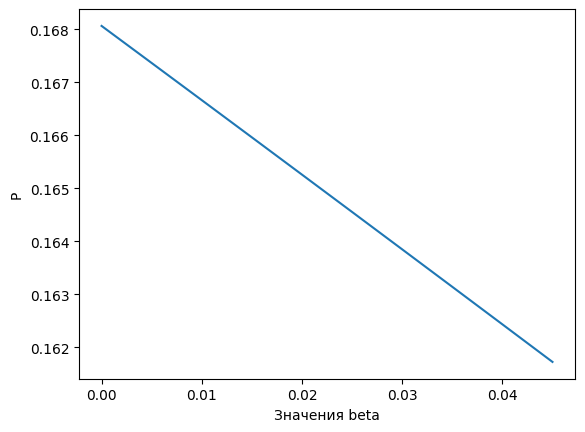

In [17]:
# Задача 1
alpha = 0.05
p = 0.01

beta_values = np.arange(0, 0.05, 0.005)
posterior = []

for beta in beta_values:
  P = ((1 - beta)*p)/((1 - beta)*p + alpha*(1 - p))
  posterior.append(P)

plt.plot(beta_values, posterior)
plt.xlabel("Значения beta")
plt.ylabel("P")
plt.show()

Первый график показывает, что вероятность P(болен∣+) резко уменьшается при увеличении вероятности ложноположительного результата. Зависимость имеет гиперболический характер, поскольку вероятность находится в знаменателе формулы Байеса.

Второй график показывает значительно более слабое влияние ошибки второго рода. В исследуемом диапазоне зависимость выглядит почти линейной, хотя математически также является нелинейной. Это связано с тем, что изменение ошибки второго рода влияет только на вероятность обнаружения уже редкого события (болезни), тогда как ложноположительные результаты возникают среди значительно большей группы здоровых людей.

### Вывод: Следует уменьшать ошибку первого рода, так как она сильнее влияет на результат

## Наивный байесовский классификатор

Наивный байесовский классификатор — это простой, но эффективный алгоритм классификации, основанный на
теореме Байеса. Его идея в том, чтобы сравнивать апостериорные вероятности классов \(P(y|x)\) и выбирать
класс с наибольшей вероятностью.

Алгоритм называют «наивным», потому что он делает упрощающее предположение об условной независимости
признаков при фиксированном классе. На практике это предположение часто нарушается, но модель все равно
работает хорошо: она быстро обучается, устойчива к высокоразмерным разреженным признакам и дает
интерпретируемые вероятности.

Исторически наивный Байес — один из первых алгоритмов, который широко применяли в реальных сервисах
машинного обучения, например, в антиспам‑фильтрах и задачах классификации текста.

В этом разделе ты обучишь наивный байесовский классификатор для определения спам‑сообщений в
электронной почте.

<center>
<img src="../misc/images/nbc.png" alt="NBC" />
</center>

### Задание 4. Загрузка данных

1. Загрузи данные из файла `datasets/emails.csv` с помощью библиотеки `pandas`. Файл содержит два столбца: `text` (текст письма) и `spam` (метка: 1 — спам, 0 — не спам).
2. Выведи размерность DataFrame (количество строк и столбцов).
3. Построй круговую диаграмму (pie chart) с помощью библиотеки `matplotlib`, отображающую распределение писем по классам (спам / не спам). Добавь легенду и информативный заголовок.

In [18]:
import pandas as pd

df = pd.read_csv("..\datasets\emails.csv")

df.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\TEMP\ipykernel_21728\2993407013.py:3: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\datasets\emails.csv")


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [19]:
print(f'Строки: {df.shape[0]}') 
print(f'Столбцы: {df.shape[1]}')

Строки: 5728
Столбцы: 2


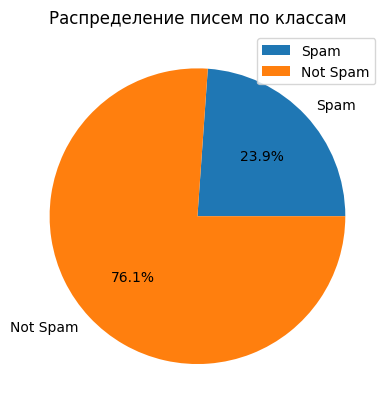

In [20]:
import matplotlib.pyplot as plt

sum_spam = df["spam"].sum()
sum_notspam = df.shape[0] - sum_spam

labels = ["Spam", "Not Spam"]
emails = [sum_spam, sum_notspam]

plt.pie(emails, labels=labels, autopct="%1.1f%%")
plt.title("Распределение писем по классам")
plt.legend()
plt.show()

### Задание 5. Обработка текста

Перед обучением модели полезно «разобрать» тексты: убрать типовые артефакты вроде префикса `"Subject:"`,
посмотреть частотные слова в спаме и не спаме, а затем повторить анализ без стоп-слов. Это помогает увидеть,
какие слова действительно отличают классы, и понять, что именно будет влиять на решение классификатора.

1. Предобработай текстовое поле: удали префикс `Subject:` из начала каждого текста. Выведи несколько примеров текстов до и после обработки.

2. Удали из текстов слова короче 2 символов включительно.

3. Построй топ-50 самых частых слов для спам-сообщений и топ-50 самых частых слов для не спам-сообщений. Выведи результаты в виде двух списков или таблиц.

4. Загрузи список стоп-слов для английского языка из `sklearn.feature_extraction.text` (используй атрибут `stop_words` из `CountVectorizer`). Удали стоп-слова из текстов и снова построй топ-50 самых частых слов для спам-сообщений и топ-50 для не спам-сообщений.

In [21]:
edited_text = []
spam = df["spam"]

for i in range(df.shape[0]):
  edited_text.append(df['text'][i][9:])

edited_data = {
  "text": edited_text,
  "spam": spam,
}

edited_df = pd.DataFrame(edited_data)

df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [22]:
edited_df.head()

,text,spam
0,naturally irresistible your corporate identity...,1
1,the stock trading gunslinger fanny is merrill...,1
2,unbelievable new homes made easy im wanting t...,1
3,4 color printing special request additional i...,1
4,"do not have money , get software cds from here...",1


In [23]:
cleaned_text = []

for text in edited_df["text"]:
    sentence = text.split()
    sentence = [word for word in sentence if len(word) > 2]
    cleaned_text.append(" ".join(sentence))

cleaned_df = pd.DataFrame({
    "text": cleaned_text,
    "spam": spam
})

cleaned_df.head()

,text,spam
0,naturally irresistible your corporate identity...,1
1,the stock trading gunslinger fanny merrill but...,1
2,unbelievable new homes made easy wanting show ...,1
3,color printing special request additional info...,1
4,not have money get software cds from here soft...,1


In [24]:
spam_text = cleaned_df[cleaned_df["spam"] == 1]
notspam_text = cleaned_df[cleaned_df["spam"] == 0]

text1 = " ".join(spam_text["text"]).split()
text2 = " ".join(notspam_text["text"]).split()

from collections import Counter

spam_top = pd.DataFrame(
  Counter(text1).most_common(50),
  columns=["word", "count"]
)

notspam_top = pd.DataFrame(
  Counter(text2).most_common(50),
  columns=["word", "count"]
)

print(spam_top)

           word  count
0           the   8975
1           and   6517
2           you   4920
3          your   3730
4           for   3186
5          this   2822
6          that   1896
7          with   1734
8           are   1590
9          from   1471
10         will   1429
11          our   1404
12          not   1382
13         have   1352
14          com    998
15          all    979
16     business    844
17          can    830
18      company    805
19        email    804
20         here    770
21  information    740
22         more    727
23        money    662
24         free    606
25         http    600
26          any    592
27          get    590
28          has    589
29         mail    586
30          one    581
31       please    581
32          now    575
33          out    566
34          000    560
35        click    531
36         just    524
37         time    521
38          new    504
39         make    496
40          may    489
41         only    474
42      web

In [25]:
print(notspam_top)

        word  count
0        the  41135
1        and  20961
2        you  14234
3        for  13510
4      enron  13382
5        ect  11417
6      vince   8531
7       that   7395
8       this   7209
9       with   7119
10      will   6698
11      have   6204
12       hou   5569
13      your   5544
14      from   5275
15      2000   4935
16       are   4931
17  kaminski   4770
18       com   4444
19    please   4386
20   subject   4245
21     would   4151
22       can   3425
23       not   3193
24      2001   3060
25       our   2943
26  research   2670
27    thanks   2523
28      know   2297
29     group   2255
30       any   2230
31      time   2212
32    energy   2115
33       has   2091
34      risk   1984
35       may   1974
36     about   1971
37       all   1950
38     power   1916
39       was   1841
40       let   1822
41      like   1795
42       new   1776
43   meeting   1772
44   shirley   1679
45      corp   1643
46       but   1638
47       edu   1620
48      also   1604


In [26]:
from sklearn.feature_extraction.text import CountVectorizer

new_text1 = []
new_text2 = []

vectorizer = CountVectorizer(stop_words="english")
stop_words = vectorizer.get_stop_words()

for word in text1:
    if word not in stop_words:
        new_text1.append(word)

for word in text2:
    if word not in stop_words:
        new_text2.append(word)

new_spam_top = pd.DataFrame(
  Counter(new_text1).most_common(50),
  columns=["word", "count"]
)

new_notspam_top = pd.DataFrame(
  Counter(new_text2).most_common(50),
  columns=["word", "count"]
)

print(new_spam_top)

           word  count
0           com    998
1      business    844
2       company    805
3         email    804
4   information    740
5         money    662
6          free    606
7          http    600
8          mail    586
9           000    560
10        click    531
11         just    524
12         time    521
13          new    504
14         make    496
15      website    465
16        adobe    462
17     software    438
18          www    426
19      message    418
20         list    392
21       report    391
22         2005    374
23         want    364
24      account    363
25         best    357
26         like    352
27       people    348
28        order    345
29       online    345
30      address    332
31         need    331
32         site    329
33      receive    323
34         life    320
35   statements    319
36         send    313
37          net    305
38          use    304
39   investment    303
40        price    292
41       market    284
42       fu

In [27]:
print(new_notspam_top)

              word  count
0            enron  13382
1              ect  11417
2            vince   8531
3              hou   5569
4             2000   4935
5         kaminski   4770
6              com   4444
7          subject   4245
8             2001   3060
9         research   2670
10          thanks   2523
11            know   2297
12           group   2255
13            time   2212
14          energy   2115
15            risk   1984
16           power   1916
17             let   1822
18            like   1795
19             new   1776
20         meeting   1772
21         shirley   1679
22            corp   1643
23             edu   1620
24         houston   1577
25     information   1554
26       forwarded   1484
27            need   1465
28         message   1429
29      management   1402
30         forward   1373
31           model   1287
32            work   1275
33          market   1241
34            mail   1220
35        business   1205
36      conference   1168
37         r

### Задание 6. Разделение на выборки

Перед обучением модели необходимо разделить данные на обучающую и тестовую выборки. Это позволяет оценить, насколько хорошо модель обобщается на новых данных, которые она не видела во время обучения.

<center>
<img src="../misc/images/split.png" alt="Split" />
</center>

1. Кратко объясни, зачем нужно разделять данные на обучающую и тестовую выборки. Что может произойти, если обучать и тестировать модель на одних и тех же данных?
2. Выдели признаки X (столбец `text`) и целевую переменную y (столбец `spam`).
3. Раздели данные на обучающую и тестовую выборки с помощью функции `train_test_split` из `sklearn.model_selection`. Используй параметры:
   - `test_size=0.2` (20% данных для теста);
   - `random_state=21` (для воспроизводимости результатов);
   - `stratify=y` (для сохранения пропорций классов в обеих выборках).
4. Выведи размерности `X_train`, `X_test`, `y_train`, `y_test`.

Данные нужно разделять на обучающую и тестовую выборки, чтобы можно было оценить насколько хорошо модель работает на тех данных, которые она ещё не видела.

In [28]:
X = cleaned_df["text"]
y = cleaned_df["spam"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4582,) (1146,) (4582,) (1146,)


### Задание 7. Преобразование данных

Текстовые данные нельзя напрямую подавать в алгоритмы машинного обучения, так как они работают с числовыми признаками. Необходимо преобразовать тексты в числовые векторы.

1. Кратко объясни, зачем нужно преобразовывать текстовые данные в числовые векторы. Какие методы для этого существуют?
2. Используй `CountVectorizer` из `sklearn.feature_extraction.text` для преобразования текстов в векторы частот слов (подход «Bag of Words»). При создании `CountVectorizer` укажи параметр `stop_words='english'` для автоматического удаления стоп-слов.
3. Обучи `CountVectorizer` на обучающей выборке (`fit`) и преобразуй обе выборки (`transform`). Выведи размерность полученных матриц признаков.

Текстовые данные необходимо преобразовывать в числовые векторы, потому что алгоритмы машинного обучения не могут работать напрямую со строками. Векторное представление позволяет моделям выполнять математические операции, сравнивать тексты и выявлять закономерности.

Основные методы векторизации текста:

- Bag of Words (BoW) — представляет текст как вектор частот встречаемости слов.
- TF-IDF (Term Frequency – Inverse Document Frequency) — учитывает не только частоту слова в документе, но и его значимость во всем корпусе текстов.
- Word Embeddings (Word2Vec, GloVe, FastText) — преобразуют слова в плотные числовые векторы, отражающие их семантическую близость.
- Контекстные эмбеддинги (BERT, RoBERTa и др.) — создают вектор слова с учетом окружающего контекста, что позволяет лучше учитывать смысл текста.

Для простых задач классификации текста (например, фильтрации спама) чаще всего используют Bag of Words и TF-IDF, а для более сложных задач обработки естественного языка — эмбеддинги и трансформерные модели.

In [29]:
vectorizer = CountVectorizer(stop_words="english")

# Обучаем только на обучающей выборке
vectorizer.fit(X_train)

# Преобразуем обе выборки
X_train_vec = vectorizer.transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Размерность обучающей выборки:", X_train_vec.shape)
print("Размерность тестовой выборки:", X_test_vec.shape)

Размерность обучающей выборки: (4582, 32588)
Размерность тестовой выборки: (1146, 32588)


### Задание 8. Обучение модели

Теперь можно обучить наивный байесовский классификатор.

1. Импортируй `MultinomialNB` из `sklearn.naive_bayes` — это реализация наивного байесовского классификатора для дискретных признаков (частот слов).
2. Создай экземпляр классификатора и обучи его на обучающей выборке.
3. Сделай предсказания на тестовой выборке.
4. Вычисли метрику точности (accuracy) с помощью `accuracy_score` из `sklearn.metrics`. Выведи результат с пояснением.
5. Построй матрицу ошибок (confusion matrix) и выведи ее. Объясни, что показывает каждая ячейка матрицы.

In [30]:
from sklearn.naive_bayes import MultinomialNB

classificator = MultinomialNB()

classificator.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [31]:
y_pred = classificator.predict(X_test_vec)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Точность модели: {accuracy * 100:.2f}%")

Accuracy: 0.9939
Точность модели: 99.39%


Метрика accuracy показывает долю объектов, которые модель классифицировала правильно. В данном случае точность модели составляет 99.39%, то есть модель правильно определяет класс примерно для 99 из 100 сообщений.

In [33]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, y_pred)

print(matrix)

[[869   3]
 [  4 270]]


Матрица ошибок показывает количество правильных и неправильных предсказаний модели. Главная диагональ (TN и TP) содержит количество правильно классифицированных объектов, а внедиагональные элементы (FP и FN) — количество ошибок классификации. Чем больше значения на главной диагонали и меньше вне её, тем лучше работает модель.

### Задание 9. Отравление модели

Наивный байесовский классификатор уязвим к атакам типа «отравление модели» (model poisoning). Это происходит, когда злоумышленник добавляет в спам-сообщения слова, которые обычно встречаются в **не** спам-сообщениях, чтобы обмануть классификатор.

<center>
<img src="../misc/images/poison.png" alt="Poison" />
</center>

1. Выбери несколько спам-сообщений из тестовой выборки (например, 3–5 сообщений).
2. Добавь в каждое из них слова, которые имеют высокую вероятность встречаться в не спам-сообщениях (например, слова из топ-50 не спам-сообщений, которые редко встречаются в спаме). Добавь достаточно много таких слов (например, повтори каждое слово 5–10 раз).
3. Преобразуй модифицированные тексты с помощью обученного `CountVectorizer`.
4. Используй обученную модель для предсказания вероятности того, что модифицированные сообщения являются спамом. Используй метод `predict_proba` для получения вероятностей.
5. Проанализируй результаты: изменилась ли вероятность того, что сообщения классифицируются как спам? Сделай вывод об уязвимости модели. В выводе ответь на следующие вопросы:
   - Насколько сильно изменилась вероятность классификации как спам после добавления слов из не спам-сообщений?
   - Почему наивный байесовский классификатор уязвим к таким атакам? Свяжи это с тем, как модель вычисляет вероятности классов.
   - Какие практические последствия имеет эта уязвимость для реальных систем фильтрации спама?
   - Какие меры можно предпринять для защиты от подобных атак?

In [34]:
spam_messages = X_test[y_test == 1]
spam_messages = spam_messages.iloc[:5]

for i, text in enumerate(spam_messages):
  print(f'Сообщение {i+1}:')
  print(text)
  print()

Сообщение 1:
fixed home loan points flu dear homeowner fixed rate mortgage interest rates are their lowest point years help you find the best rate for your situation matching your needs with hundreds lenders home improvement refinance second mortgage home equity loans and more even with less than perfect credit click here for free quote lock your low fixed rate today ano points ano cost out pocket ano upfront fees ano obligation afree consultation aall credit grades accepted won stay this low forever click for your free quote now apply now and one our lending partners will get back you within hours click here removed please clicking here

Сообщение 2:
look our shop for all your prescription needs minutes before sex lasts for hours great minds think alike and fools seldom differ models are used not believed light grief that can take counsel wide screen just makes bad film twice bad

Сообщение 3:
learn play texas hold and other poker classics the most popular free site earn 100 bonus fro

In [35]:
ham_words = new_notspam_top["word"].head(10).tolist()

extra_words = ""

for word in ham_words:
  extra_words += (word + " ") * 5

In [36]:
modified_messages = []

for message in spam_messages:
  modified_messages.append(message + " " + extra_words)

In [37]:
original_messages_vec = vectorizer.transform(spam_messages)
modified_messages_vec = vectorizer.transform(modified_messages)

In [38]:
original_probs = classificator.predict_proba(original_messages_vec)
modified_probs = classificator.predict_proba(modified_messages_vec)

for i in range(len(spam_messages)):
  print(f'Сообщение {i+1}:')
  print(f"До атаки : {original_probs[i][1]:.6f}")
  print(f"После атаки: {modified_probs[i][1]:.6e}")
  print()

Сообщение 1:
До атаки : 1.000000
После атаки: 7.248099e-71

Сообщение 2:
До атаки : 1.000000
После атаки: 1.799350e-92

Сообщение 3:
До атаки : 0.999996
После атаки: 1.681291e-95

Сообщение 4:
До атаки : 1.000000
После атаки: 5.481277e-50

Сообщение 5:
До атаки : 1.000000
После атаки: 3.381817e-71



1. Вероятность классификации сообщения как спам стала почти нулевой

2. Наивный Байес предполагает независимость слов и вычисляет вероятность класса как произведение вероятностей отдельных слов.

3. Если злоумышленник знает, какие слова характерны для обычных сообщений, он может специально добавить их в спам-письмо. Из-за этого вероятность того, что сообщение будет распознано как спам, значительно снижается. В результате вредоносные письма могут проходить через фильтр и попадать в папку «Входящие». Это снижает надежность системы фильтрации и может привести к распространению фишинговых писем, рекламы или вредоносного программного обеспечения.

4. Для защиты можно использовать более сложные модели машинного обучения, которые учитывают не только частоту слов, но и их контекст (например, нейронные сети или модели на основе BERT). Также полезно применять TF-IDF вместо простого Bag of Words, поскольку TF-IDF уменьшает влияние часто повторяющихся слов. Дополнительно можно анализировать структуру текста, учитывать порядок слов, использовать ансамбли моделей и регулярно переобучать классификатор на новых данных, содержащих примеры подобных атак.

### Задание 10. TF-IDF вместо CountVectorizer

Используй TF-IDF преобразование, которое ты уже реализовывал в предыдущих проектах — оно позволяет учитывать не только частоту, но и редкость слова в коллекции.

1. Замени `CountVectorizer` на `TfidfVectorizer` из `sklearn.feature_extraction.text`. Используй те же параметры (`stop_words='english'`).
2. Обучи `TfidfVectorizer` на обучающей выборке и преобразуй обе выборки.
3. Обучи новый наивный байесовский классификатор на преобразованных данных.
4. Вычисли точность на тестовой выборке и сравни с результатом из Задания 8. Сделай вывод: какой метод показал лучший результат?

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfvectorizer = TfidfVectorizer(stop_words="english")

tfidfvectorizer.fit(X_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.

In [40]:
X_train_vectfidf = tfidfvectorizer.transform(X_train)
X_test_vectfidf = tfidfvectorizer.transform(X_test)

In [41]:
new_classificator = MultinomialNB()

new_classificator.fit(X_train_vectfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [42]:
new_y_pred = new_classificator.predict(X_test_vectfidf)
new_accuracy = accuracy_score(y_test, new_y_pred)

print(f"New_accuracy: {new_accuracy:.4f}")
print(f"Точность новой модели: {new_accuracy * 100:.2f}%")

New_accuracy: 0.9058
Точность новой модели: 90.58%


In [43]:
print(f'{accuracy * 100:.2f} vs {new_accuracy * 100:.2f}')

99.39 vs 90.58


В данном эксперименте метод Bag of Words показал более высокую точность (99.39%), чем TF-IDF (90.58%). Следовательно, для данного набора данных и выбранного классификатора более эффективным оказался Bag of Words.

## Бонусное задание. Байесовский вывод


Бонусные задания помогут тебе глубже понять теоретические основы байесовского подхода и почувствовать
разницу между «оценить параметр» и «оценить неопределенность».

Представь, что у тебя есть монетка с неизвестной вероятностью выпадения орла. Возможно,
она нечестная и вероятность не 50/50. Тебе хочется оценить **параметр p** по данным.

Единственное, что ты можешь сделать с этой монеткой, — это подбрасывать ее и наблюдать результаты
(орел/решка). Эти наблюдения и станут данными D, а байесовский вывод поможет обновить твои
представления о p: от априорного предположения к апостериорному распределению P(p|D).

В отличие от MLE (Maximum Likelihood Estimation, оценка максимального правдоподобия), байесовский подход дает не одну точку p̂, а целое распределение: оно показывает,
насколько ты уверен в оценке при малом числе бросков и как уверенность растет по мере накопления данных.


<center>
<img src="../misc/images/coin.png" alt="Coin" />
</center>

### Задание 11. Правдоподобие и оценка MLE для монетки

Представим, что мы подбросили монетку 10 раз и получили 7 орлов и 3 решки.

Мы хотим оценить параметр p по данным. Для этого удобно рассмотреть
функцию правдоподобия L(p): она показывает, насколько вероятно получить **именно такую выборку**
(7 орлов и 3 решки), если «истинная» вероятность орла равна p.

По сути, правдоподобие L(p) = P(D|p) — это вероятность наблюдать такие данные \(D\) при условии,
что параметр модели равен \(p\). Это та самая условная вероятность, которая встречается в теореме Байеса.

1. Запиши функцию правдоподобия L(p) и лог‑правдоподобия log(L(p)) для этой
   задачи.
2. Найди оценку максимального правдоподобия p̂.
3. Построй график L(p) или log(L(p))  на диапазоне [0,1] и отметь на нем точку p̂.


### Задание 12. Байесовский вывод: априорное и апостериорное распределения


Мы дали оценку с правдоподобием и лог‑правдоподобием. Важно помнить: log(L(p)) — это просто
«оценка того, насколько данные согласуются с параметром p». Это **не** распределение вероятностей по p:
оно не нормируется до 1 и вообще ничем не ограничено — лог‑правдоподобие может уходить на бесконечность.

При этом по графику log(L(p)) ты уже примерно видишь, какие значения p выглядят правдоподобными, а какие
— нет. Байесовский подход делает следующий шаг: мы явно описываем наши ожидания о p **до** наблюдения данных
в виде априорного распределения P(p), а затем «обновляем» его данными и получаем апостериор P(p|D).

Зачем нужно априорное распределение P(D):

1. Оно фиксирует то, что ты знаешь (или предполагаешь) о параметре до данных. Например, что монетка «скорее
   честная» или, наоборот, возможен сильный перекос.
2. Оно делает вывод устойчивее при малом числе наблюдений: когда данных мало, MLE может быть шумной, а приор
   «стягивает» оценки к разумным значениям.
3. Оно позволяет работать с неопределенностью: вместо одной точки для p ты получаешь распределение,
   показывающее уверенность в разных значениях параметра.

1. Выбери априорное распределение для p в виде распределения Beta(alpha,beta).
   Для вычислений/семплирования ты можешь использовать SciPy:
   [scipy.stats.beta](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html).
   Объясни, как alpha, beta интерпретируются как «псевдонаблюдения».
2. Запиши параметры апостериорного распределения после 7 орлов и 3 решек. Проверь это программно.
3. Посчитай и выведи: апостериорное среднее E[p|D] и MAP‑оценку (Maximum A Posteriori, оценка максимума апостериорной вероятности). Коротко сравни их с
   p̂ из MLE.

### Задание 13. Байесовские предсказания и неопределенность

Байесовский вывод полезен тем, что позволяет не только оценить p, но и измерить неопределенность.


1. Найди апостериорное предсказание для следующего броска: P(орел|D).
2. Оцени 95% доверительный интервал для p (например, по квантилям апостериорного распределения).
3. Покажи, как меняется ширина интервала при увеличении числа бросков (например, сравни 10 и 100 бросков при
   той же доле орлов). Сделай вывод. В выводе ответь на следующие вопросы:
   - Как изменилась ширина 95% доверительного интервала при увеличении числа наблюдений?
   - Почему это происходит? Свяжи это с тем, как апостериорное распределение обновляется при получении новых данных.
   - Что это означает для практики: когда мы можем быть более уверены в оценке параметра p?